In [14]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [15]:
# Load IMDB dataset
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=10000)

word_index = tf.keras.datasets.imdb.get_word_index()

reverse_word_index = {
    value + 3: key
    for key, value in word_index.items()
}

reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])

train_text = [decode_review(review) for review in train_data]
test_text = [decode_review(review) for review in test_data]

df = pd.DataFrame({
    "review_text": train_text,
    "label": train_labels
})

df.head()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,review_text,label
0,<START> this film was just brilliant casting l...,1
1,<START> big hair big boobs bad music and a gia...,0
2,<START> this has to be one of the worst films ...,0
3,<START> the <UNK> <UNK> at storytelling the tr...,1
4,<START> worst mistake of my life br br i picke...,0


Dataset Shape: (25000, 2)

Label Distribution:
label
1    12500
0    12500
Name: count, dtype: int64


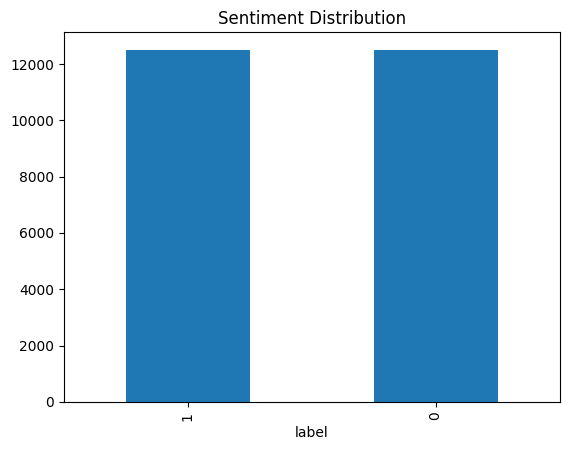

In [16]:
print("Dataset Shape:", df.shape)

print("\nLabel Distribution:")
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

In [17]:
df["review_text"] = df["review_text"].fillna("")

print(df.isnull().sum())

review_text    0
label          0
dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_text,
    train_labels,
    test_size=0.2,
    random_state=42
)

In [19]:
VOCAB_SIZE = 10000
SEQUENCE_LENGTH = 200

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

vectorizer.adapt(X_train)

In [20]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).batch(32)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
).batch(32)

train_ds = train_ds.map(
    lambda x, y: (vectorizer(x), y)
)

val_ds = val_ds.map(
    lambda x, y: (vectorizer(x), y)
)

In [21]:
model = tf.keras.Sequential([
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=16,
        input_length=SEQUENCE_LENGTH
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["binary_accuracy"]
)

In [23]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8
)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - binary_accuracy: 0.7219 - loss: 0.5757 - val_binary_accuracy: 0.8342 - val_loss: 0.4169
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - binary_accuracy: 0.8625 - loss: 0.3432 - val_binary_accuracy: 0.8574 - val_loss: 0.3381
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - binary_accuracy: 0.8955 - loss: 0.2707 - val_binary_accuracy: 0.8636 - val_loss: 0.3236
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - binary_accuracy: 0.9121 - loss: 0.2315 - val_binary_accuracy: 0.8632 - val_loss: 0.3235
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - binary_accuracy: 0.9251 - loss: 0.2035 - val_binary_accuracy: 0.8652 - val_loss: 0.3297
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - binary_accuracy: 0.9354 - loss: 0.1811 - val_binary_accuracy: 0.8624 - val_loss: 0.3404
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - binary_accuracy: 0.9430 - loss: 0.1623 - val_binary_accuracy: 0.8596 - val_loss: 0.3545
Epoch 8/8


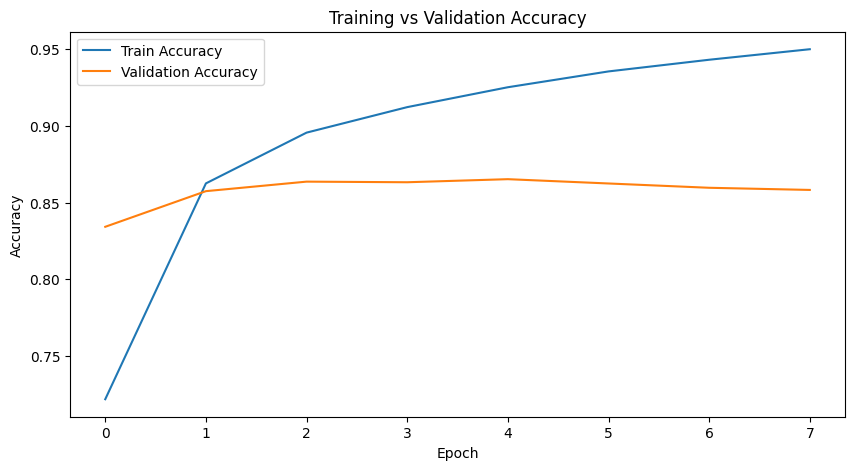

In [24]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["binary_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_binary_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [25]:
test_ds = tf.data.Dataset.from_tensor_slices(
    (test_text, test_labels)
).batch(32)

test_ds = test_ds.map(
    lambda x, y: (vectorizer(x), y)
)

loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.8457 - loss: 0.4034
Test Accuracy: 0.8457199931144714


In [26]:
sample_review = [
    "The product arrived broken and I am very unhappy"
]

vectorized_review = vectorizer(sample_review)

prediction = model.predict(vectorized_review)

print("Sentiment Score:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Sentiment Score: 0.21675105


In [27]:
score = prediction[0][0]

if score < 0.2:
    print("Strong Negative")
elif score < 0.5:
    print("Negative")
elif score < 0.8:
    print("Positive")
else:
    print("Strong Positive")

Negative


In [28]:
def review_routing(score):

    if score < 0.2:
        return "URGENT SUPPORT TICKET"

    elif score < 0.5:
        return "Customer Service Review"

    else:
        return "No Action Required"

In [29]:
print(review_routing(prediction[0][0]))

Customer Service Review
